<a href="https://colab.research.google.com/github/Meenakrishnan-work/Meenakrishnan-work.github.io/blob/main/ML_sample_heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Step 1 — Objective
Build a binary classification model that predicts whether a patient has heart disease (1) or not (0) based on clinical features (age, blood pressure, cholesterol, chest pain type, etc.). This is a high-impact healthcare problem where early detection saves lives.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             roc_curve, mean_squared_error)
from imblearn.over_sampling import SMOTE

In [ ]:
print("=" * 60)
print("OBJECTIVE : Predict heart disease (binary classification)")
print("DATASET   : UCI Heart Disease - Cleveland (303 samples)")
print("=" * 60)

# Data Collection - load from UCI repository
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
       "heart-disease/processed.cleveland.data")
cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']
df  = pd.read_csv(url, names=cols)

# Replace '?' with NaN, convert to numeric
df = df.replace('?', np.nan)
for c in df.columns:
    df[c] = pd.to_numeric(df[c])

# Binarize target: 0 = no disease, 1 = disease
df['target'] = (df['target'] > 0).astype(int)

print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['target'].value_counts())

OBJECTIVE : Predict heart disease (binary classification)
DATASET   : UCI Heart Disease - Cleveland (303 samples)

Shape: (303, 14)

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Class distribution:
 target
0    164
1    139
Name: count, dtype: int64


In [ ]:
# -------- 3. PREPROCESSING --------
# (a) Handle Missing Values - median imputation
imputer = SimpleImputer(strategy='median')
df_imp  = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

X = df_imp.drop('target', axis=1)
y = df_imp['target']

# (b) Resampling - SMOTE for class balance
X_res, y_res = SMOTE(random_state=42).fit_resample(X, y)
print("\nAfter SMOTE:", dict(pd.Series(y_res).value_counts()))

# (c) Normalization - StandardScaler
X_scaled = StandardScaler().fit_transform(X_res)

# (d) Train-Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res)

# (e) Cross-Validation - Stratified K-Fold (MANDATORY)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Cross-Validation: 5-Fold StratifiedKFold\n")


After SMOTE: {0.0: np.int64(164), 1.0: np.int64(164)}
Cross-Validation: 5-Fold StratifiedKFold



In [ ]:
# -------- 4. MULTIPLE MODELS --------
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(random_state=42),
    'SVM'                : SVC(probability=True, random_state=42),
    'KNN'                : KNeighborsClassifier(),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=42),
}

--- Logistic Regression ---
  CV=0.8284±0.0409  Acc=0.8485  Prec=0.8286  Rec=0.8788  Spec=0.8182  F1=0.8529  MSE=0.1515  RMSE=0.3892  AUC=0.9183

--- Decision Tree ---
  CV=0.7708±0.0392  Acc=0.7273  Prec=0.7027  Rec=0.7879  Spec=0.6667  F1=0.7429  MSE=0.2727  RMSE=0.5222  AUC=0.7273

--- Random Forest ---
  CV=0.8282±0.0243  Acc=0.8485  Prec=0.8485  Rec=0.8485  Spec=0.8485  F1=0.8485  MSE=0.1515  RMSE=0.3892  AUC=0.9109

--- SVM ---
  CV=0.8474±0.0268  Acc=0.8485  Prec=0.8485  Rec=0.8485  Spec=0.8485  F1=0.8485  MSE=0.1515  RMSE=0.3892  AUC=0.9146

--- KNN ---
  CV=0.8396±0.0294  Acc=0.8333  Prec=0.7750  Rec=0.9394  Spec=0.7273  F1=0.8493  MSE=0.1667  RMSE=0.4082  AUC=0.8916

--- Gradient Boosting ---
  CV=0.8052±0.0230  Acc=0.8182  Prec=0.8000  Rec=0.8485  Spec=0.7879  F1=0.8235  MSE=0.1818  RMSE=0.4264  AUC=0.8907

FINAL COMPARISON TABLE
              Model  CV Acc  Accuracy  Precision  Recall  Specificity     F1    MSE   RMSE    AUC
Logistic Regression  0.8284    0.8485     0.8286 

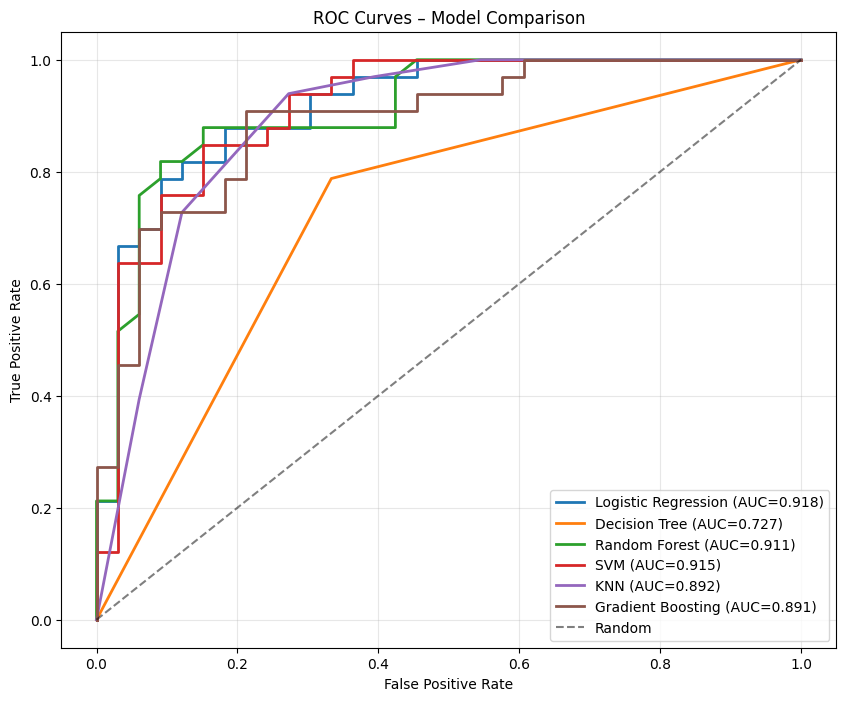

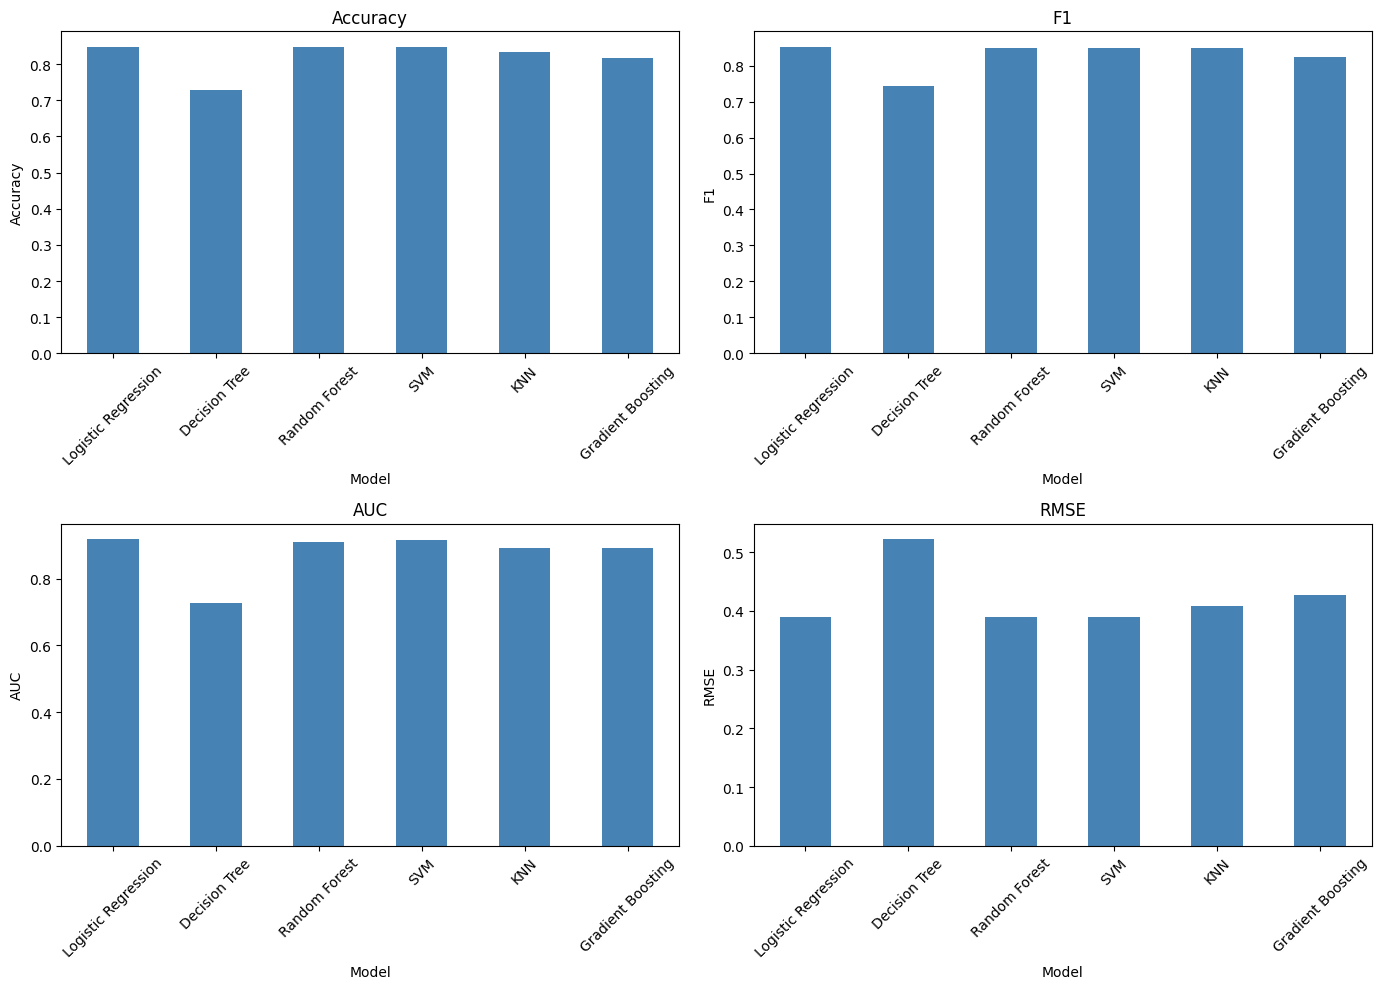

In [ ]:
# -------- 5. EVALUATION --------
results, roc_data = [], {}

for name, model in models.items():
    print(f"--- {name} ---")

    # 5-fold CV on training set
    cv = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')

    # Fit on full training set, predict on test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Confusion matrix → TN, FP, FN, TP
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Metrics
    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred)
    rec   = recall_score(y_test, y_pred)          # Sensitivity
    spec  = tn / (tn + fp)                        # Specificity
    f1    = f1_score(y_test, y_pred)
    mse   = mean_squared_error(y_test, y_pred)
    rmse  = np.sqrt(mse)
    auc   = roc_auc_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)

    results.append({
        'Model': name, 'CV Acc': cv.mean(),
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'Specificity': spec,
        'F1': f1, 'MSE': mse, 'RMSE': rmse, 'AUC': auc
    })
    print(f"  CV={cv.mean():.4f}±{cv.std():.4f}  Acc={acc:.4f}  "
          f"Prec={prec:.4f}  Rec={rec:.4f}  Spec={spec:.4f}  F1={f1:.4f}  "
          f"MSE={mse:.4f}  RMSE={rmse:.4f}  AUC={auc:.4f}\n")

# Results table
res_df = pd.DataFrame(results)
print("=" * 60)
print("FINAL COMPARISON TABLE")
print("=" * 60)
print(res_df.round(4).to_string(index=False))

# -------- ROC CURVES --------
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Model Comparison')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.show()

# -------- METRIC BAR CHARTS --------
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
for a, m in zip(ax.ravel(), ['Accuracy', 'F1', 'AUC', 'RMSE']):
    res_df.plot(x='Model', y=m, kind='bar', ax=a, legend=False, color='steelblue')
    a.set_title(m); a.set_ylabel(m); a.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

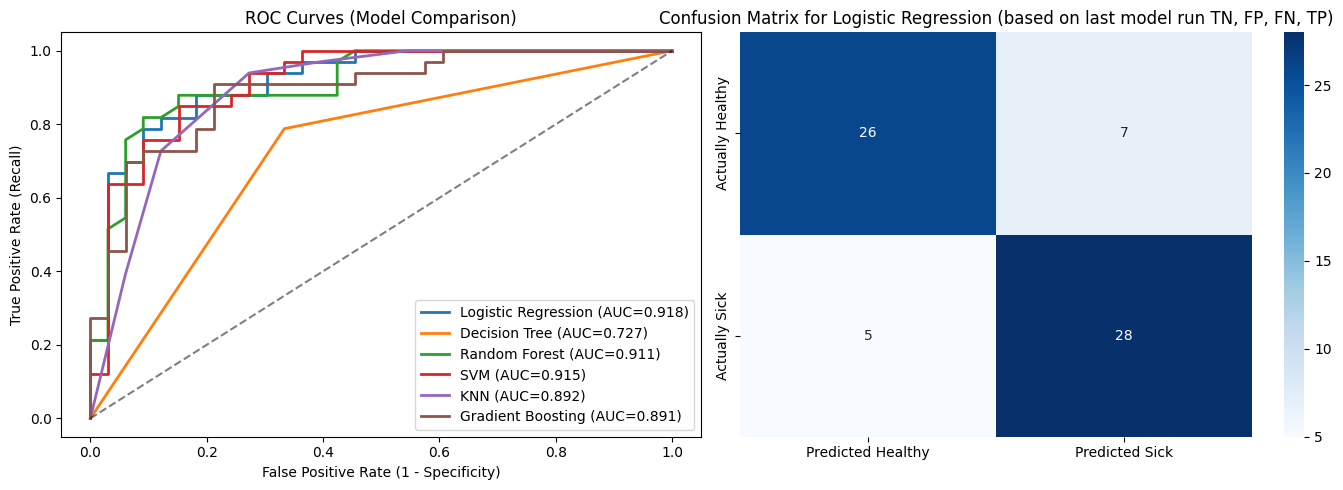

In [ ]:
# -------- 5. VISUALIZE BUSINESS IMPACT --------
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curves
for name, (fpr, tpr, auc) in roc_data.items():
    ax[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax[0].set_title('ROC Curves (Model Comparison)')
ax[0].set_xlabel('False Positive Rate (1 - Specificity)')
ax[0].set_ylabel('True Positive Rate (Recall)')
ax[0].legend()

# Plot 2: Confusion Matrix of Tuned Best Model
# Determine the best model based on AUC
best_model_name = res_df.loc[res_df['AUC'].idxmax()]['Model']

cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=['Predicted Healthy','Predicted Sick'],
            yticklabels=['Actually Healthy','Actually Sick'])
ax[1].set_title(f'Confusion Matrix for {best_model_name} (based on last model run TN, FP, FN, TP)')

plt.tight_layout()
plt.show()